/var/folders/9w/hykx30j92h11_5dq0nb94yth0000gn/T/ipykernel_6435/242645010.py:9: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(file_path, sr=None)


Datei erfolgreich geladen: ../data/raw/S1000R_201X_YoutubeBikeAndBuggy_CamChainRattle.m4a
Abtastrate: 44100 Hz
Dauer: 13.60 Sekunden


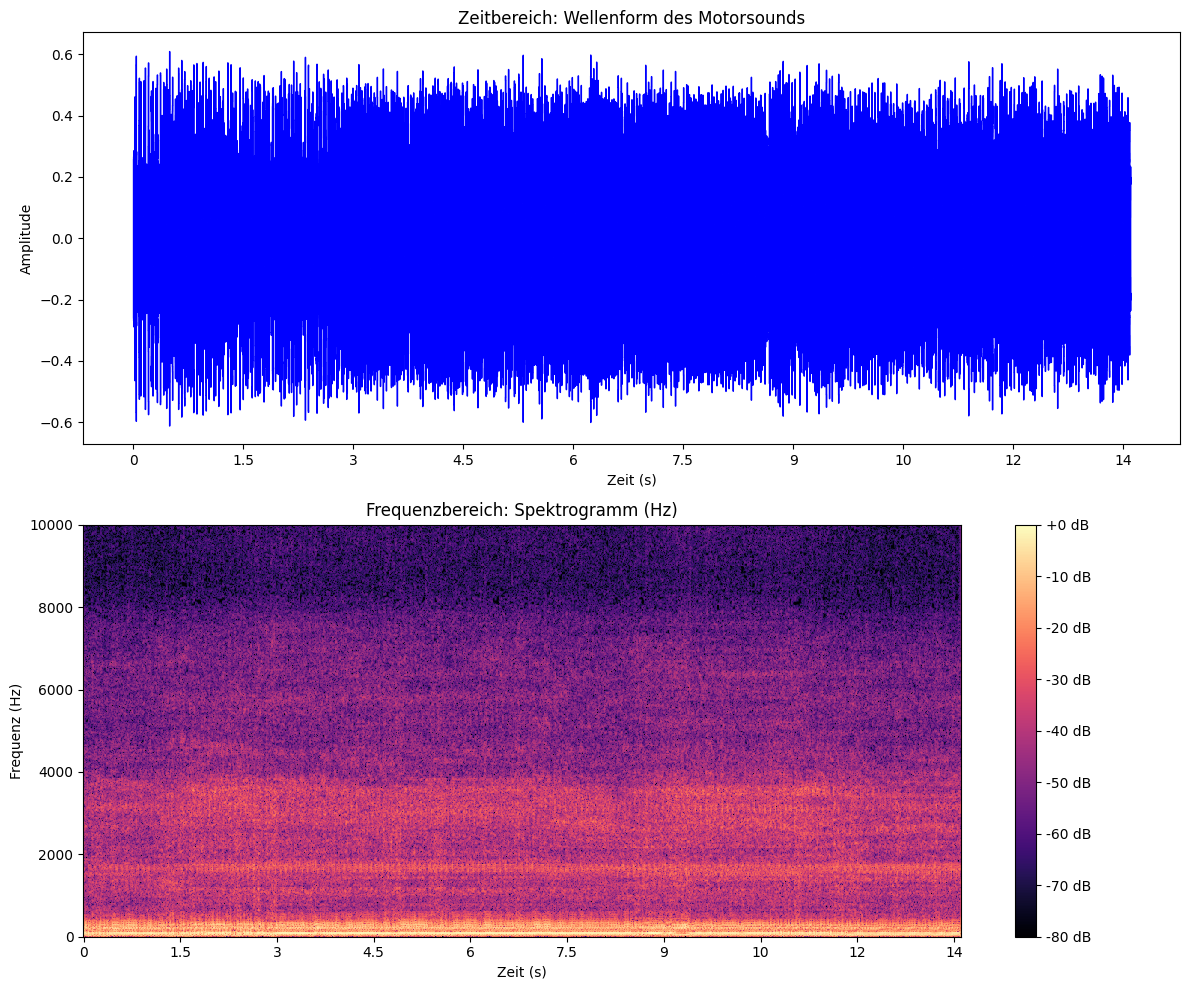

In [8]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

# 1. Datei laden
file_path = '../data/raw/S1000R_201X_YoutubeBikeAndBuggy_CamChainRattle.m4a'
# sr=None behält die original Abtastrate bei (meist 44.1kHz oder 48kHz)
y, sr = librosa.load(file_path, sr=None)

print(f"Datei erfolgreich geladen: {file_path}")
print(f"Abtastrate: {sr} Hz")
print(f"Dauer: {len(y)/sr:.2f} Sekunden")

# 2. Plotting vorbereiten
plt.figure(figsize=(12, 10))

# --- Zeitbereich (Waveform) ---
plt.subplot(2, 1, 1)
librosa.display.waveshow(y, sr=sr, color='blue')
plt.title('Zeitbereich: Wellenform des Motorsounds')
plt.xlabel('Zeit (s)')
plt.ylabel('Amplitude')

# --- Frequenzbereich (Spektrogramm) ---
# Wir nutzen eine Kurzzeit-Fourier-Transformation (STFT)
D = librosa.stft(y)  # STFT berechnen
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max) # In Dezibel umrechnen

plt.subplot(2, 1, 2)
img = librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='hz')
plt.colorbar(img, format='%+2.0f dB')
plt.title('Frequenzbereich: Spektrogramm (Hz)')
plt.ylim(0, 10000)  # Fokus auf den Bereich bis 15kHz (relevante Mechanik)
plt.xlabel('Zeit (s)')
plt.ylabel('Frequenz (Hz)')

plt.tight_layout()
plt.show()

# Vergleich André und Philip

In [234]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize

# 1. Parameter optimiert für 24kHz
START_SEC = 1
DURATION_SEC = 15
TARGET_SR = 48000
N_MELS = 512        # Reduziert von 512, um die "Empty filters" Warnung zu beheben
HOP_LENGTH = 8
N_FFT = 4096

def load_slice_mel(file_path):
    # 'sr=TARGET_SR' sorgt für konsistente Daten
    y, sr = librosa.load(file_path, sr=TARGET_SR, offset=START_SEC, duration=DURATION_SEC)
    
    # n_mels=256 ist bei 24kHz SR das Maximum für saubere Filter
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS, 
                                       n_fft=N_FFT, hop_length=HOP_LENGTH)
    S_db = librosa.power_to_db(S, ref=np.max)
    return S_db

# 2. Daten laden
path_andre = '../data/raw/rechts_andre.m4a'
path_philip = '../data/raw/rechts_philip.m4a'

mel_andre = load_slice_mel(path_andre)
mel_philip = load_slice_mel(path_philip)

min_width = min(mel_andre.shape[1], mel_philip.shape[1])
mel_andre = mel_andre[:, :min_width]
mel_philip = mel_philip[:, :min_width]
mel_diff = np.abs(mel_andre - mel_philip)

/var/folders/9w/hykx30j92h11_5dq0nb94yth0000gn/T/ipykernel_90429/4120221238.py:17: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(file_path, sr=TARGET_SR, offset=START_SEC, duration=DURATION_SEC)
/opt/anaconda3/envs/s1000-diagnoser/lib/python3.11/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


Optimaler Time-Lag: -48921 Frames (ca. -8.153 Sekunden)


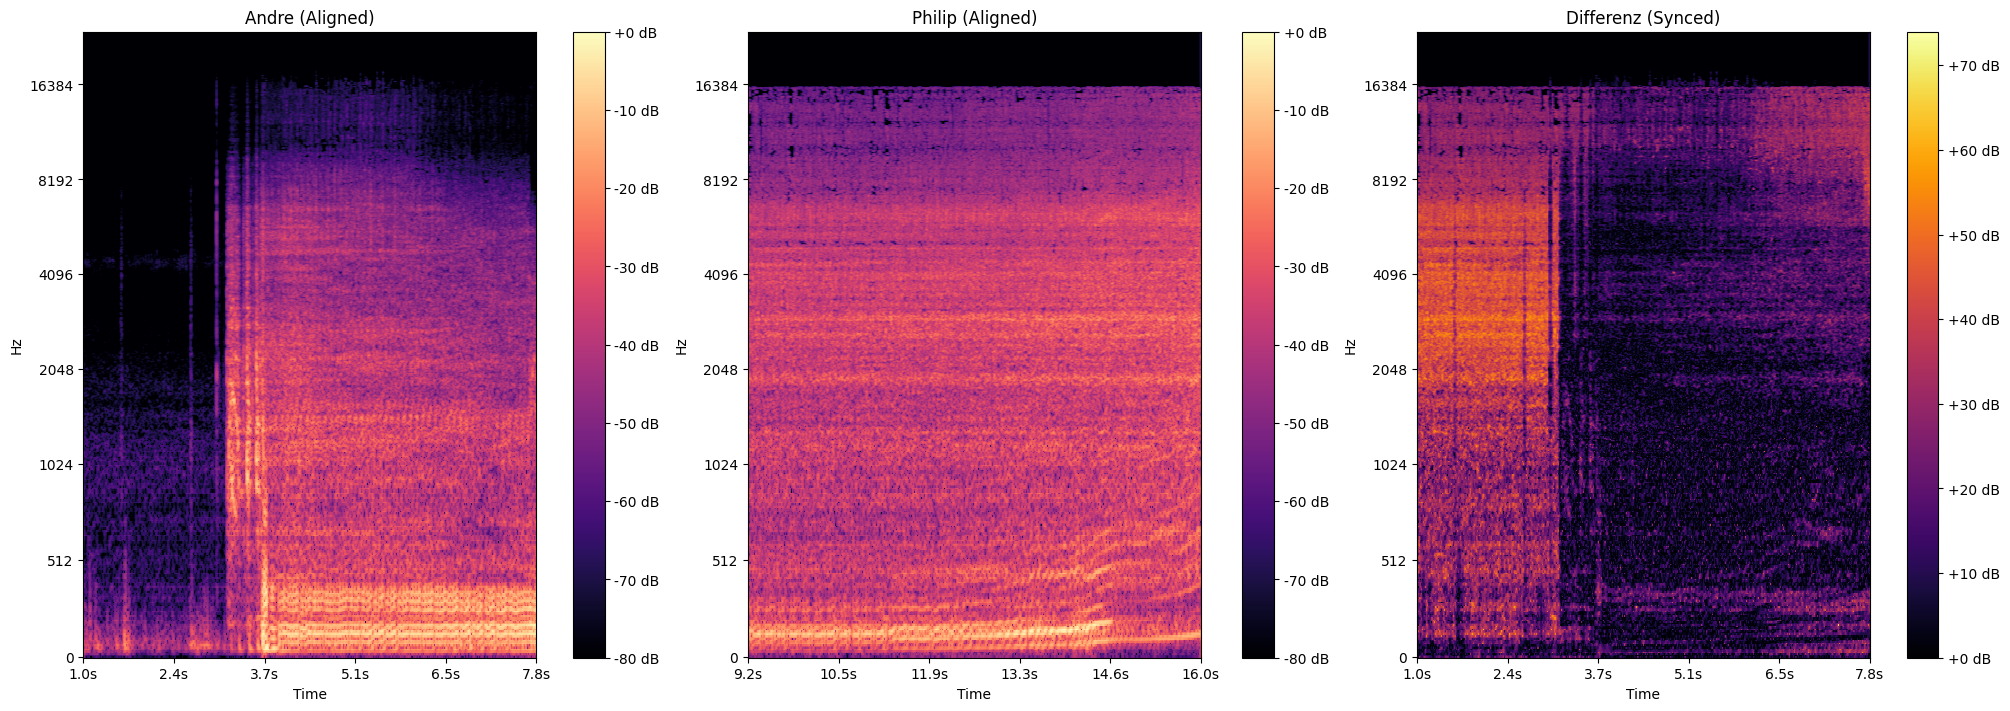

In [235]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize
from scipy.signal import correlate

# --- 1. Synchronisations-Logik ---
def synchronize_signals(spec_a, spec_b):
    # Mittlere Energie über alle Frequenzen (Rhythmus-Extraktion)
    env_a = np.mean(spec_a, axis=0)
    env_b = np.mean(spec_b, axis=0)
    
    # Zero-mean Normalisierung für bessere Korrelation
    env_a = env_a - np.mean(env_a)
    env_b = env_b - np.mean(env_b)
    
    # Kreuzkorrelation
    corr = correlate(env_a, env_b, mode='full')
    lag = np.argmax(corr) - (len(env_b) - 1)
    return lag

# Lag berechnen (basierend auf deinen bereits geladenen mel_andre / mel_philip)
lag = synchronize_signals(mel_andre, mel_philip)
lag_sec = lag * HOP_LENGTH / TARGET_SR
print(f"Optimaler Time-Lag: {lag} Frames (ca. {lag_sec:.3f} Sekunden)")

# Signale verschieben und zuschneiden
if lag > 0:
    mel_andre_sync = mel_andre[:, lag:]
    mel_philip_sync = mel_philip[:, :-lag]
    actual_start_philip = START_SEC
    actual_start_andre = START_SEC + lag_sec
elif lag < 0:
    lag_abs = abs(lag)
    mel_andre_sync = mel_andre[:, :-lag_abs]
    mel_philip_sync = mel_philip[:, lag_abs:]
    actual_start_philip = START_SEC + abs(lag_sec)
    actual_start_andre = START_SEC
else:
    mel_andre_sync, mel_philip_sync = mel_andre.copy(), mel_philip.copy()
    actual_start_philip = actual_start_andre = START_SEC

# Neue Dauer berechnen
new_duration = mel_andre_sync.shape[1] * HOP_LENGTH / TARGET_SR
mel_diff_sync = np.abs(mel_andre_sync - mel_philip_sync)

# --- 2. Visualisierung ---
fig, axes = plt.subplots(1, 3, figsize=(20, 7), constrained_layout=True)

norm = Normalize(vmin=min(mel_andre_sync.min(), mel_philip_sync.min()), 
                 vmax=max(mel_andre_sync.max(), mel_philip_sync.max()))

def plot_spec_dynamic(data, title, ax, start_time, duration, norm_obj=None, cmap='magma'):
    img = librosa.display.specshow(data, sr=TARGET_SR, hop_length=HOP_LENGTH, 
                                   x_axis='time', y_axis='mel', 
                                   ax=ax, norm=norm_obj, cmap=cmap)
    ax.set_title(title)
    
    # Zeitachse mit Dezimalstellen beschriften (angepasst an neuen Startwert)
    tick_positions = np.linspace(0, duration, 6)
    ax.set_xticks(tick_positions)
    ax.set_xticklabels([f"{(x + start_time):.1f}s" for x in tick_positions])
    return img

# Plots erstellen
img1 = plot_spec_dynamic(mel_andre_sync, 'Andre (Aligned)', axes[0], actual_start_andre, new_duration, norm)
img2 = plot_spec_dynamic(mel_philip_sync, 'Philip (Aligned)', axes[1], actual_start_philip, new_duration, norm)
img3 = plot_spec_dynamic(mel_diff_sync, 'Differenz (Synced)', axes[2], actual_start_andre, new_duration, cmap='inferno')

fig.colorbar(img1, ax=axes[0], format='%+2.0f dB')
fig.colorbar(img2, ax=axes[1], format='%+2.0f dB')
fig.colorbar(img3, ax=axes[2], format='%+2.0f dB')

plt.show()

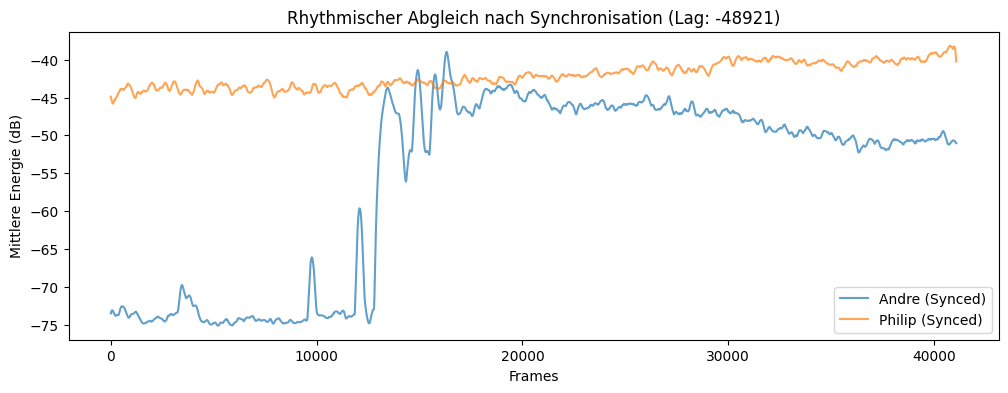

In [236]:
# Nur zur Kontrolle: Envelopes visualisieren
env_andre = np.mean(mel_andre_sync, axis=0)
env_philip = np.mean(mel_philip_sync, axis=0)

plt.figure(figsize=(12, 4))
plt.plot(env_andre, label='Andre (Synced)', alpha=0.7)
plt.plot(env_philip, label='Philip (Synced)', alpha=0.7)
plt.title(f'Rhythmischer Abgleich nach Synchronisation (Lag: {lag})')
plt.xlabel('Frames')
plt.ylabel('Mittlere Energie (dB)')
plt.legend()
plt.show()

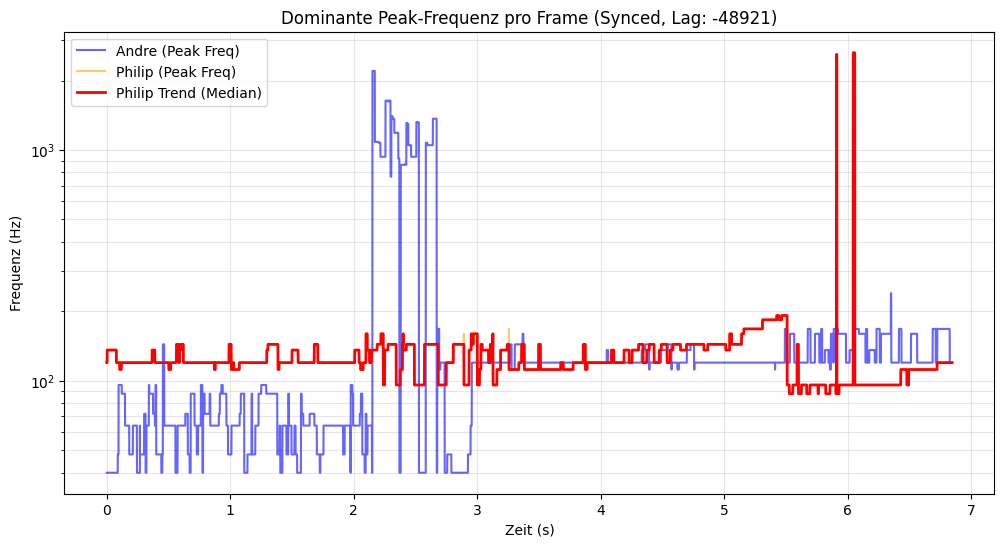

In [237]:
# 1. Zeitachse basierend auf der Frame-Anzahl der synchronisierten Daten erstellen
# Ein Frame entspricht HOP_LENGTH / TARGET_SR Sekunden
num_frames_sync = mel_andre_sync.shape[1]
frame_duration = HOP_LENGTH / TARGET_SR
time_axis_sync = np.arange(num_frames_sync) * frame_duration

# 2. Die Frequenzen der Mel-Bänder (Y-Achse)
melfreqs = librosa.mel_frequencies(n_mels=N_MELS, fmin=0.0, fmax=TARGET_SR / 2)

# 3. Indizes der Spitzenfrequenzen (dein Ansatz)
env_andre = np.argmax(mel_andre_sync, axis=0)
env_philip = np.argmax(mel_philip_sync, axis=0)

# 4. Umrechnung der Indizes in echte Frequenzen (Hz)
env_andre_hz = melfreqs[env_andre]
env_philip_hz = melfreqs[env_philip]

# 5. Visualisierung
plt.figure(figsize=(12, 6))

# Andre plotten
plt.plot(time_axis_sync, env_andre_hz, label='Andre (Peak Freq)', alpha=0.6, color='blue')

# Philip plotten
plt.plot(time_axis_sync, env_philip_hz, label='Philip (Peak Freq)', alpha=0.6, color='orange')

# Hilfreich: Ein gleitender Durchschnitt, um den Trend der Drehzahl besser zu sehen
import pandas as pd
smooth_philip = pd.Series(env_philip_hz).rolling(window=15, center=True).median()
plt.plot(time_axis_sync, smooth_philip, color='red', linewidth=2, label='Philip Trend (Median)')

plt.title(f'Dominante Peak-Frequenz pro Frame (Synced, Lag: {lag})')
plt.xlabel('Zeit (s)')
plt.ylabel('Frequenz (Hz)')
plt.yscale('log') # Log-Skala hilft, da Motorfrequenzen oft unten liegen
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.legend()
plt.show()

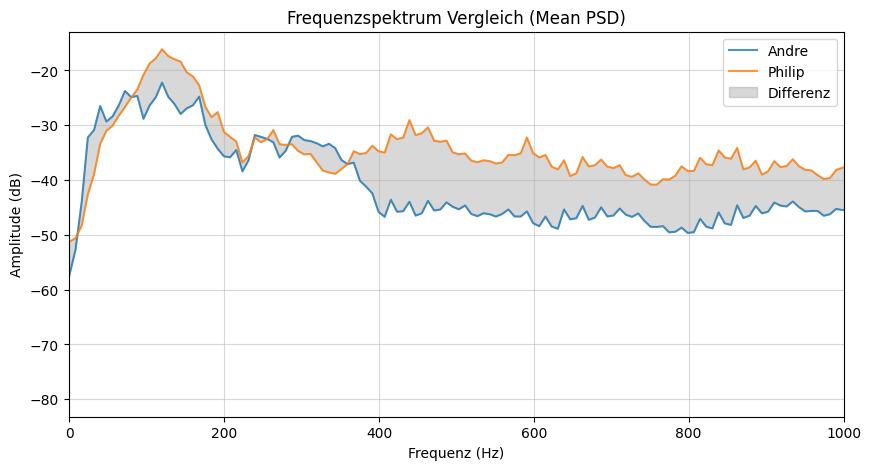

In [238]:
plt.figure(figsize=(10, 5))
# Mittelwert über die Zeitachse (axis=1)
mean_andre = np.mean(mel_andre_sync, axis=1)
mean_philip = np.mean(mel_philip_sync, axis=1)

# Frequenzachse für den Plot erstellen
freqs = librosa.mel_frequencies(n_mels=N_MELS, fmin=0, fmax=TARGET_SR/2)

plt.plot(freqs, mean_andre, label='Andre', alpha=0.8)
plt.plot(freqs, mean_philip, label='Philip', alpha=0.8)
plt.fill_between(freqs, mean_andre, mean_philip, color='gray', alpha=0.3, label='Differenz')

#plt.xscale('log') # Logarithmisch sieht man die Unterschiede besser
plt.title('Frequenzspektrum Vergleich (Mean PSD)')
plt.xlabel('Frequenz (Hz)')
plt.ylabel('Amplitude (dB)')
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.xlim(-1,1000)
plt.show()

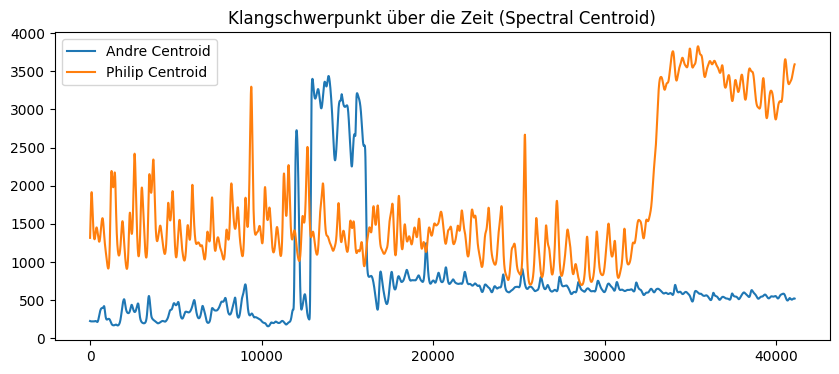

In [239]:
# Beispiel-Code für den Spectral Centroid
centroid_andre = librosa.feature.spectral_centroid(S=librosa.db_to_power(mel_andre_sync))[0]
centroid_philip = librosa.feature.spectral_centroid(S=librosa.db_to_power(mel_philip_sync))[0]

plt.figure(figsize=(10, 4))
plt.plot(centroid_andre, label='Andre Centroid')
plt.plot(centroid_philip, label='Philip Centroid')
plt.title('Klangschwerpunkt über die Zeit (Spectral Centroid)')
plt.legend()
plt.show()

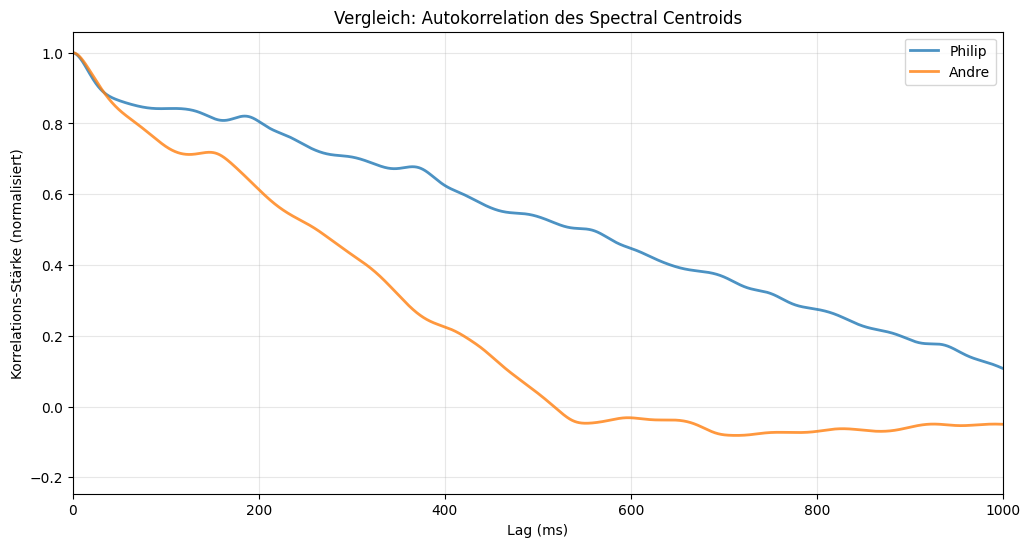

Philip - Dominanter Rhythmus-Peak: 40.00 ms (entspricht ca. 1500 bpm / u/min)
Andre  - Dominanter Rhythmus-Peak: 40.00 ms (entspricht ca. 1500 bpm / u/min)


In [240]:
from scipy.signal import correlate

# 1. Daten vorbereiten (Zentrieren, um Bias zu vermeiden)
c_philip = centroid_philip - np.mean(centroid_philip)
c_andre = centroid_andre - np.mean(centroid_andre)

# 2. Autokorrelation berechnen für beide
# Philip
auto_corr_p = correlate(c_philip, c_philip, mode='full')
auto_corr_p = auto_corr_p[len(auto_corr_p)//2:]

# Andre
auto_corr_a = correlate(c_andre, c_andre, mode='full')
auto_corr_a = auto_corr_a[len(auto_corr_a)//2:]

# 3. Zeitachse für die Korrelation (in Millisekunden)
# Da beide auf denselben Parametern basieren, reicht eine Zeitachse
time_lags = np.arange(len(auto_corr_p)) * (HOP_LENGTH / TARGET_SR)

# 4. Plotten (Vergleich im selben Graph)
plt.figure(figsize=(12, 6))
plt.plot(time_lags * 1000, auto_corr_p / np.max(auto_corr_p), label='Philip', alpha=0.8, linewidth=2)
plt.plot(time_lags * 1000, auto_corr_a / np.max(auto_corr_a), label='Andre', alpha=0.8, linewidth=2)

plt.title('Vergleich: Autokorrelation des Spectral Centroids')
plt.xlabel('Lag (ms)')
plt.ylabel('Korrelations-Stärke (normalisiert)')
plt.xlim(0, 1000) # Fokus auf Leerlauf-Bereich bis 250ms
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 5. Peaks finden (außer dem Peak bei 0ms)
def get_main_peak(corr_data, lags):
    # Wir überspringen die ersten 10-15ms, um nicht den Start-Peak zu fangen
    min_lag_idx = int(0.040 * TARGET_SR / HOP_LENGTH) 
    peak_idx = np.argmax(corr_data[min_lag_idx:]) + min_lag_idx
    return lags[peak_idx] * 1000

peak_p = get_main_peak(auto_corr_p, time_lags)
peak_a = get_main_peak(auto_corr_a, time_lags)

print(f"Philip - Dominanter Rhythmus-Peak: {peak_p:.2f} ms (entspricht ca. {60000/(peak_p):.0f} bpm / u/min)")
print(f"Andre  - Dominanter Rhythmus-Peak: {peak_a:.2f} ms (entspricht ca. {60000/(peak_a):.0f} bpm / u/min)")

/var/folders/9w/hykx30j92h11_5dq0nb94yth0000gn/T/ipykernel_90429/2934804996.py:15: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(file_path, sr=TARGET_SR)
/opt/anaconda3/envs/s1000-diagnoser/lib/python3.11/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
/opt/anaconda3/envs/s1000-diagnoser/lib/python3.11/site-packages/librosa/feature/spectral.py:2143: UserWarning: Empty filters detected in mel frequency basis. Some channels will produce empty responses. Try increasing your sampling rate (and fmax) or reducing n_mels.
  mel_basis = filters.mel(sr=sr, n_fft=n_fft, **kwargs)


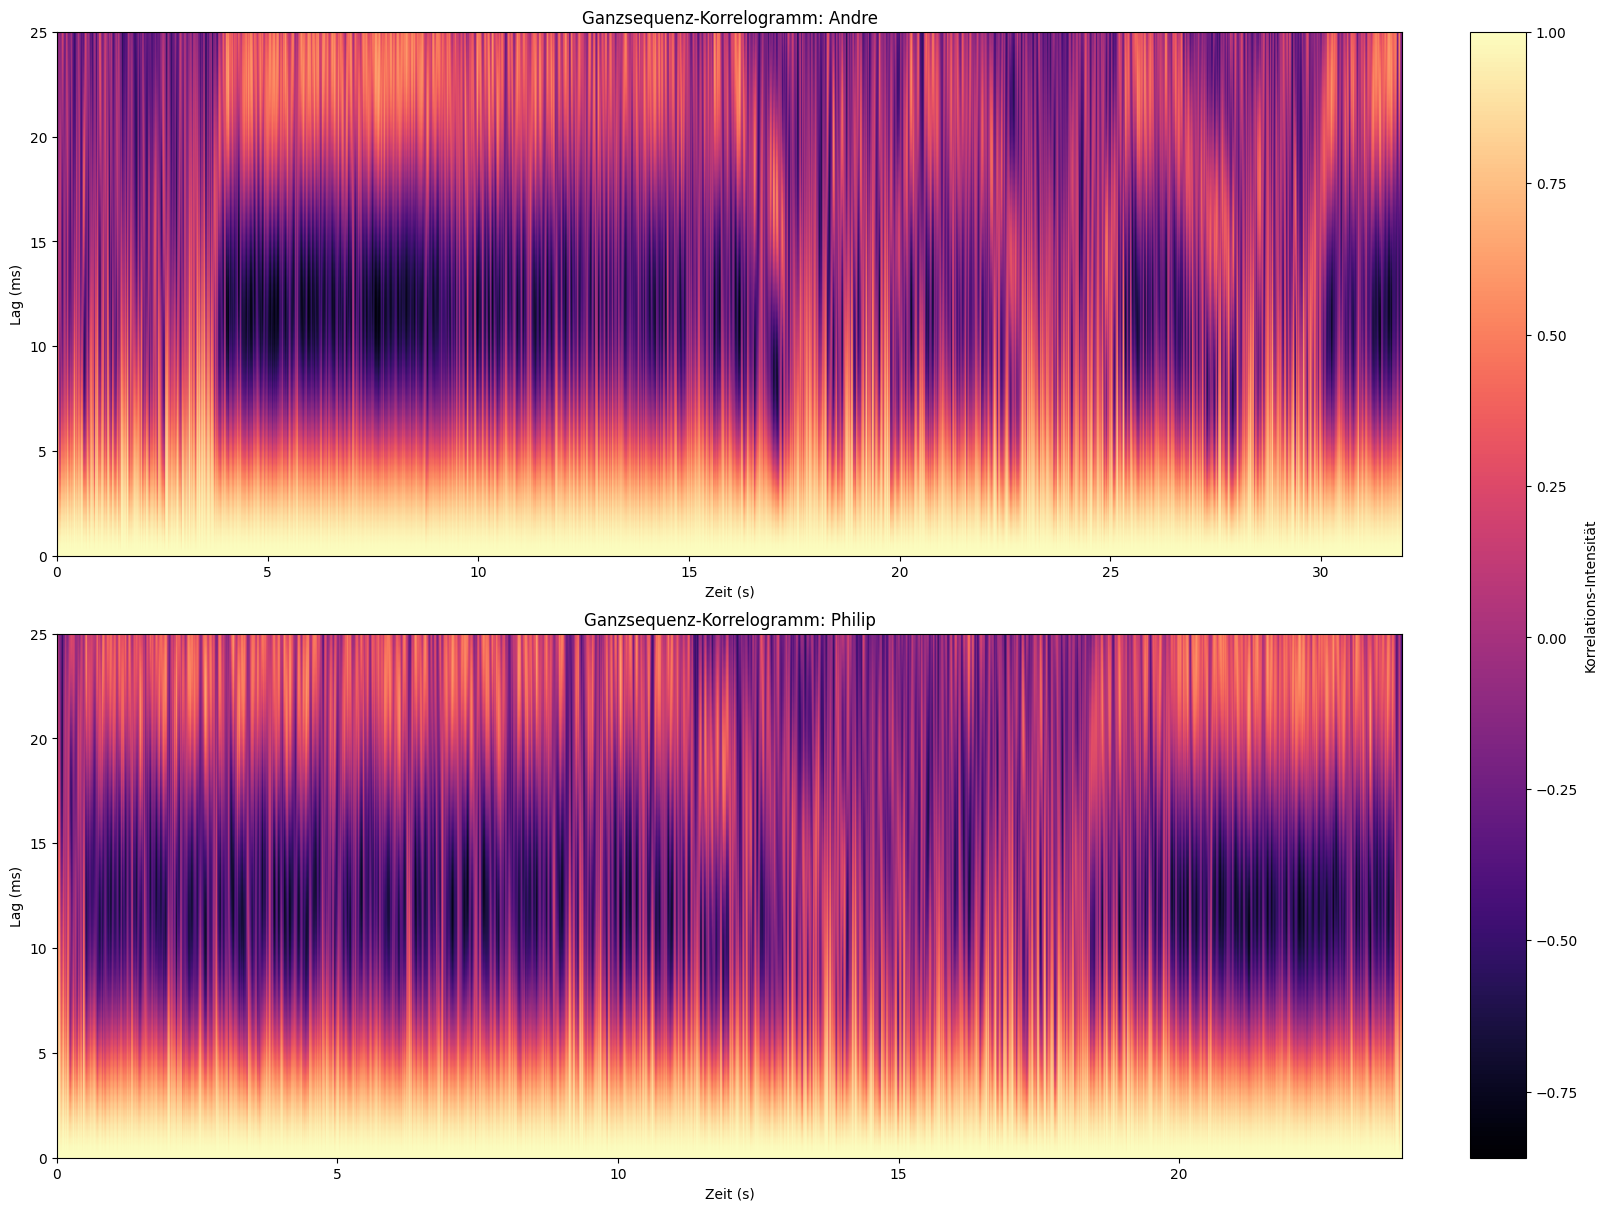

In [241]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import correlate

# 1. Parameter für die gesamte Sequenz
TARGET_SR = 48000
HOP_LENGTH = 16
N_MELS = 512
N_FFT = 1024

def process_full_correlogram(file_path):
    # Die ganze Datei laden (ohne offset/duration)
    y, sr = librosa.load(file_path, sr=TARGET_SR)
    duration = len(y) / sr
    
    # Mel-Spektrogramm für die ganze Länge
    S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH)
    S_db = librosa.power_to_db(S, ref=np.max)
    
    # Korrelogramm berechnen
    win_size = 200  # Etwas größeres Fenster für mehr Stabilität beim Sweep
    step_size = 1  # Größere Schritte für schnellere Berechnung bei langen Files
    
    num_steps = (S_db.shape[1] - win_size) // step_size
    correlogram = []

    for i in range(num_steps):
        start = i * step_size
        end = start + win_size
        segment = np.mean(S_db[:, start:end], axis=0)
        segment -= np.mean(segment)
        
        corr = correlate(segment, segment, mode='full')
        corr = corr[len(corr)//2:]
        # Normalisierung pro Zeitschritt (lokale Normalisierung)
        if np.max(corr) > 0:
            correlogram.append(corr / np.max(corr))
        else:
            correlogram.append(corr)

    return np.array(correlogram).T, duration

# 2. Daten verarbeiten
path_andre = '../data/raw/rechts_andre.m4a'
path_philip = '../data/raw/rechts_philip.m4a'

corr_a, dur_a = process_full_correlogram(path_andre)
corr_p, dur_p = process_full_correlogram(path_philip)

# 3. Visualisierung
fig, axes = plt.subplots(2, 1, figsize=(16, 12), constrained_layout=True)

# Wir limitieren den Lag auf 200ms (reicht für alles über 300 u/min)
max_lag_ms = 25
max_lag_idx = int(max_lag_ms / (1000 * HOP_LENGTH / TARGET_SR))

def plot_full_corr(data, title, ax, duration):
    img = ax.imshow(data[:max_lag_idx, :], aspect='auto', origin='lower', cmap='magma',
                    extent=[0, duration, 0, max_lag_ms])
    ax.set_title(title)
    ax.set_xlabel('Zeit (s)')
    ax.set_ylabel('Lag (ms)')
    return img

img1 = plot_full_corr(corr_a, 'Ganzsequenz-Korrelogramm: Andre', axes[0], dur_a)
img2 = plot_full_corr(corr_p, 'Ganzsequenz-Korrelogramm: Philip', axes[1], dur_p)

fig.colorbar(img1, ax=axes, label='Korrelations-Intensität')
plt.show()

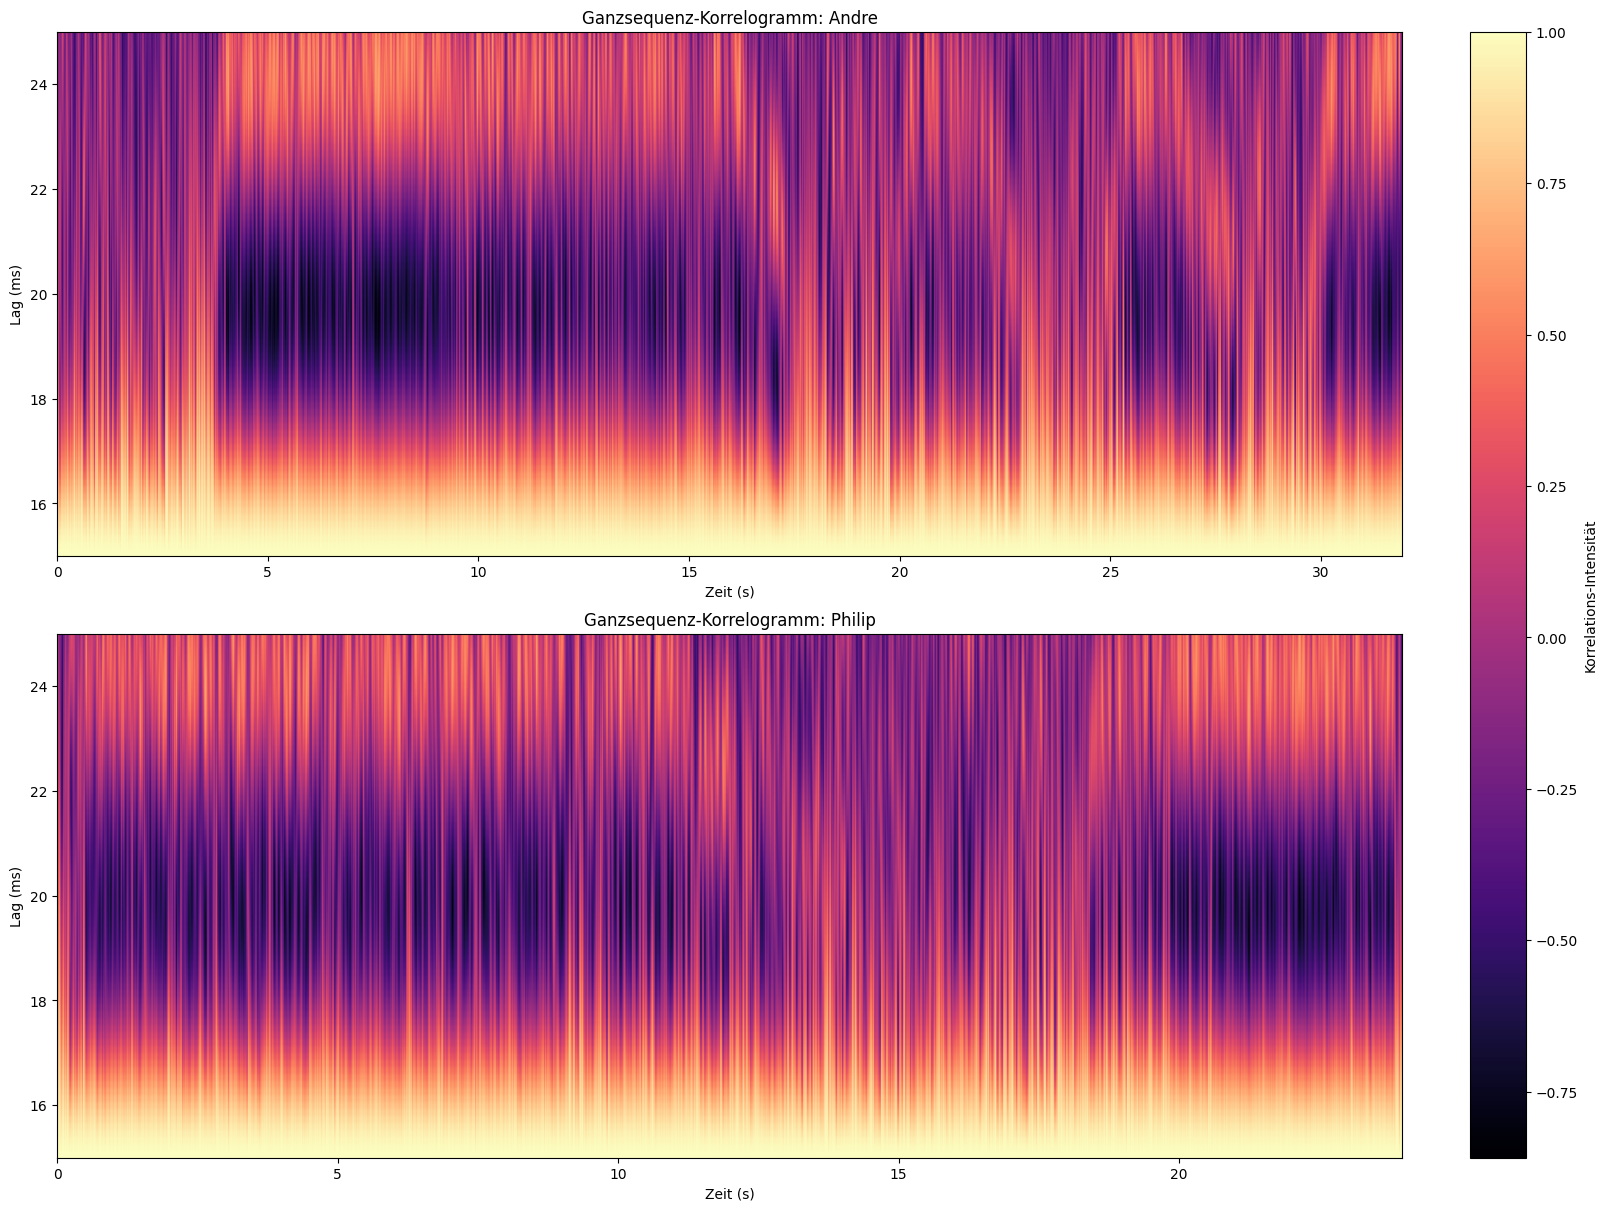

In [242]:
# 3. Visualisierung
fig, axes = plt.subplots(2, 1, figsize=(16, 12), constrained_layout=True)

# Wir limitieren den Lag auf 200ms (reicht für alles über 300 u/min)
max_lag_ms = 25
max_lag_idx = int(max_lag_ms / (1000 * HOP_LENGTH / TARGET_SR))

def plot_full_corr(data, title, ax, duration):
    img = ax.imshow(data[:max_lag_idx, :], aspect='auto', origin='lower', cmap='magma',
                    extent=[0, duration, 15, max_lag_ms])
    ax.set_title(title)
    ax.set_xlabel('Zeit (s)')
    ax.set_ylabel('Lag (ms)')
    return img

img1 = plot_full_corr(corr_a, 'Ganzsequenz-Korrelogramm: Andre', axes[0], dur_a)
img2 = plot_full_corr(corr_p, 'Ganzsequenz-Korrelogramm: Philip', axes[1], dur_p)

fig.colorbar(img1, ax=axes, label='Korrelations-Intensität')
plt.show()

## Drehzahl extrahieren

/var/folders/9w/hykx30j92h11_5dq0nb94yth0000gn/T/ipykernel_90429/1295933435.py:16: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(PATH_PHILIP, sr=TARGET_SR)


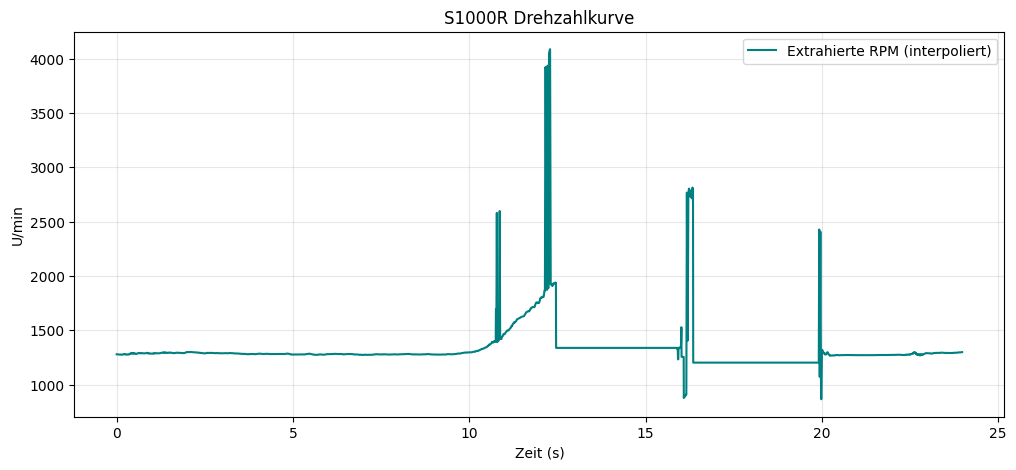

In [243]:
import numpy as np
import librosa
import pandas as pd
from scipy.signal import correlate, find_peaks
import matplotlib.pyplot as plt

# --- 1. Parameter-Konfiguration ---
TARGET_SR = 48000
HOP_LENGTH = 128
N_MELS = 512
N_FFT = 1024
PATH_PHILIP = '../data/raw/rechts_philip.m4a'
#PATH_PHILIP = '../data/raw/rechts_andre.m4a'

# --- 2. Daten laden und Spektrogramm berechnen ---
y, sr = librosa.load(PATH_PHILIP, sr=TARGET_SR)
duration = len(y) / sr

# Mel-Spektrogramm berechnen
S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS, n_fft=N_FFT, hop_length=HOP_LENGTH)
S_db = librosa.power_to_db(S, ref=np.max)

# --- 3. Korrelogramm-Berechnung ---
def compute_correlogram(spec_data, win_size=1000, step_size=1):
    num_steps = (spec_data.shape[1] - win_size) // step_size
    correlogram = []
    for i in range(num_steps):
        start = i * step_size
        end = start + win_size
        segment = np.mean(spec_data[:, start:end], axis=0)
        segment -= np.mean(segment)
        corr = correlate(segment, segment, mode='full')
        corr = corr[len(corr)//2:]
        if np.max(corr) > 0:
            correlogram.append(corr / np.max(corr))
        else:
            correlogram.append(corr)
    return np.array(correlogram).T

#corr_matrix = compute_correlogram(S_db)
corr_matrix = compute_correlogram(S)    # turns out it's better to use non-DB scale here for this feature extraction!

# Achsen definieren
lags_ms = np.arange(corr_matrix.shape[0]) * (HOP_LENGTH / TARGET_SR) * 1000
time_axis = np.linspace(0, duration, corr_matrix.shape[1])

# --- 4. Hochpräzise Drehzahl-Extraktion ---
def extract_rpm_final(correlogram, lags_ms):
    rpms = []
    # Suchbereich: 5ms (12000 U/min) bis 80ms (750 U/min)
    idx_start = np.argmin(np.abs(lags_ms - 5)) 
    idx_end = np.argmin(np.abs(lags_ms - 80))
    
    for step in range(correlogram.shape[1]):
        column = correlogram[idx_start:idx_end, step]
        peaks, properties = find_peaks(column, prominence=0.01)
        
        if len(peaks) > 0:
            best_peak_idx = peaks[np.argmax(properties['prominences'])]
            p = best_peak_idx
            
            # Parabolische Interpolation für Sub-Pixel-Genauigkeit
            if 0 < p < len(column) - 1:
                y1, y2, y3 = column[p-1], column[p], column[p+1]
                denom = (2 * (y1 - 2*y2 + y3))
                shift = (y1 - y3) / denom if denom != 0 else 0
                precise_idx = p + shift
            else:
                precise_idx = p
                
            peak_lag_ms = (precise_idx + idx_start) * (HOP_LENGTH / TARGET_SR) * 1000
            rpm = (60 * 1000) / peak_lag_ms
            
            rpms.append(rpm)
        else:
            rpms.append(np.nan)
            
    # Lücken füllen (Interpolation & moderne fillna Syntax)
    s = pd.Series(rpms)
    s = s.rolling(window=5, center=True).mean().bfill().ffill()
    #s = s.interpolate(method='linear').bfill().ffill()
    return s.values

rpms_final = extract_rpm_final(corr_matrix, lags_ms)

# --- 5. Ausgabe ---
# Start-Index für die Anzeige (z.B. ab Sekunde 2.0)
start_time_to_display = 2.0
start_idx = np.argmin(np.abs(time_axis - start_time_to_display))

"""print(f"{'Zeit (s)':<10} | {'Hochpräzise RPM':<20}")
print("-" * 35)
for i in range(start_idx, min(start_idx + 25, len(rpms_final))):
    print(f"{time_axis[i]:<10.3f} | {rpms_final[i]:<20.4f}")"""

# Optionaler Plot
plt.figure(figsize=(12, 5))
plt.plot(time_axis, rpms_final, label="Extrahierte RPM (interpoliert)", color="teal")
plt.title("S1000R Drehzahlkurve")
plt.xlabel("Zeit (s)")
plt.ylabel("U/min")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [244]:
def extract_rpm_final_v6(y, sr, hop_length):
    n_fft = 16384
    stft = np.abs(librosa.stft(y, n_fft=n_fft, hop_length=hop_length))
    freqs = librosa.fft_frequencies(sr=sr, n_fft=n_fft)
    
    # 1. Ankerpunkt (Leerlauf)
    # Wir wissen jetzt: 1350 U/min war korrekt -> ca. 22.5 Hz
    current_f = 20 
    rpms = []
    
    for i in range(stft.shape[1]):
        spectrum = stft[:, i]
        
        # Suchfenster um die letzte Frequenz (erlaubt moderates Steigen/Fallen)
        # Wir suchen in einem Korridor von +/- 20% um den letzten Wert
        f_min = max(15, current_f * 0.9)
        f_max = min(150, current_f * 1.1) # 1.3 erlaubt schnelles Hochdrehen
        
        search_idx = np.where((freqs >= f_min) & (freqs <= f_max))[0]
        
        if len(search_idx) > 0:
            # Wir suchen den Peak im Korridor
            peak_idx = search_idx[np.argmax(spectrum[search_idx])]
            current_f = freqs[peak_idx]
        
        rpms.append(current_f * 60)
    
    # Glättung
    return pd.Series(rpms).rolling(window=11, center=True).median().bfill().ffill().values

# Finale Ausführung
rpms_v6 = extract_rpm_final_v6(y, TARGET_SR, HOP_LENGTH)

print(f"FINALE Leerlauf: {np.mean(rpms_v6[:int(3/(duration/len(rpms_v6)))]):.2f} U/min")
print(f"FINALE Maximum: {np.max(rpms_v6):.2f} U/min")

FINALE Leerlauf: 1230.47 U/min
FINALE Maximum: 1230.47 U/min


In [245]:
print(rpms_v6)

[1230.46875 1230.46875 1230.46875 ... 1230.46875 1230.46875 1230.46875]


In [246]:
import matplotlib.pyplot as plt

# 1. Daten glätten für eine saubere Optik
# Ein Fenster von ca. 0.1s ist ideal für Drehzahlen
window_size = int(0.1 / (HOP_LENGTH / TARGET_SR))
if window_size % 2 == 0: window_size += 1
rpms_smooth = pd.Series(rpms_hps).rolling(window=window_size, center=True).median().bfill().ffill().values

# 2. Der kombinierte Plot
fig, ax1 = plt.subplots(figsize=(15, 8))

# Hintergrund: Das Korrelogramm (als visuelle Referenz)
img = ax1.imshow(corr_matrix[:int(100/(1000*HOP_LENGTH/TARGET_SR)), :], 
                 aspect='auto', origin='lower', cmap='magma', alpha=0.7,
                 extent=[0, duration, 0, 100]) # Lag-Achse bis 100ms
ax1.set_ylabel('Lag (ms) - Mechanischer Rhythmus')
ax1.set_xlabel('Zeit (s)')

# Zweite Y-Achse für die Drehzahl (U/min)
ax2 = ax1.twinx()
ax2.plot(time_axis_hps, rpms_smooth, color='cyan', linewidth=3, label='Extrahierte Drehzahl (HPS)')

# Layout-Feinschliff
ax2.set_ylabel('Drehzahl (U/min)')
ax2.set_ylim(0, 8000) # Fokus auf Leerlauf bis Sweep-Ende
ax2.set_title('Validierung: HPS-Drehzahlkurve über mechanischem Korrelogramm')

# Legende und Gitter
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

plt.tight_layout()
plt.show()

# 3. Statistik-Check
print(f"Leerlauf-Schnitt (0-5s): {np.mean(rpms_smooth[:int(5/(duration/len(rpms_smooth)))]):.2f} U/min")
print(f"Maximal-Drehzahl im Sweep: {np.max(rpms_smooth):.2f} U/min")

NameError: name 'rpms_hps' is not defined

/var/folders/9w/hykx30j92h11_5dq0nb94yth0000gn/T/ipykernel_90429/2372429939.py:14: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(FILE_PATH, sr=TARGET_SR)
/var/folders/9w/hykx30j92h11_5dq0nb94yth0000gn/T/ipykernel_90429/2372429939.py:49: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


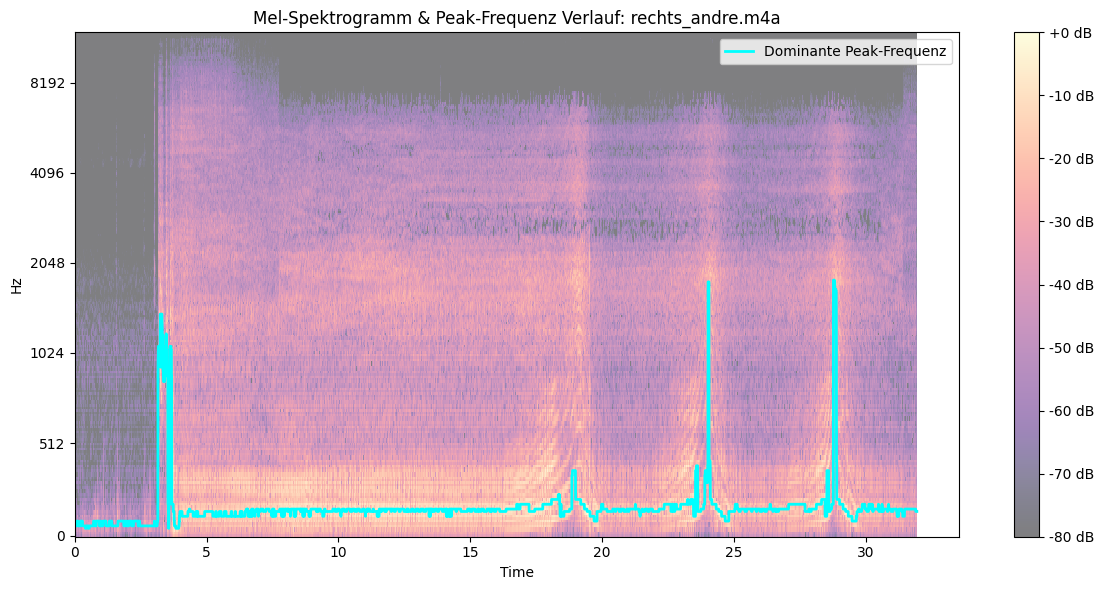

Zeit (s) | Peak-Frequenz (Hz)
-------------------------
0.00     | 53.48 Hz
1.00     | 53.48 Hz
1.99     | 53.48 Hz
2.99     | 53.48 Hz
3.99     | 133.71 Hz
4.99     | 133.71 Hz
5.98     | 106.97 Hz
6.98     | 133.71 Hz
7.98     | 147.08 Hz
8.98     | 147.08 Hz
9.97     | 147.08 Hz
10.97    | 147.08 Hz
11.97    | 147.08 Hz
12.97    | 147.08 Hz
13.96    | 133.71 Hz
14.96    | 147.08 Hz
15.96    | 133.71 Hz
16.96    | 173.82 Hz
17.95    | 173.82 Hz
18.95    | 361.01 Hz
19.95    | 133.71 Hz
20.95    | 147.08 Hz
21.94    | 133.71 Hz
22.94    | 147.08 Hz
23.94    | 361.01 Hz
24.94    | 133.71 Hz
25.93    | 147.08 Hz
26.93    | 147.08 Hz
27.93    | 133.71 Hz
28.93    | 200.56 Hz
29.92    | 173.82 Hz
30.92    | 147.08 Hz
31.92    | 133.71 Hz


In [250]:
import numpy as np
import librosa
import matplotlib.pyplot as plt
import pandas as pd

# --- 1. Parameter & Datei ---
TARGET_SR = 24000
HOP_LENGTH = 128
N_MELS = 256
FILE_PATH = '../data/raw/rechts_philip.m4a'
FILE_PATH = '../data/raw/rechts_andre.m4a'

# --- 2. Audio laden & Mel-Spektrogramm berechnen ---
y, sr = librosa.load(FILE_PATH, sr=TARGET_SR)
duration = len(y) / sr

# Mel-Spektrogramm (Power)
S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=N_MELS, n_fft=1024, hop_length=HOP_LENGTH)
# Umwandlung in Dezibel (logarithmisch), damit die Amplitudenwerte vergleichbar sind
S_db = librosa.power_to_db(S, ref=np.max)

# --- 3. Frequenz-Extraktion ---
# Zeitachse (x) und Mel-Frequenzen in Hz (y) definieren
time_axis = np.linspace(0, duration, S_db.shape[1])
melfreqs = librosa.mel_frequencies(n_mels=N_MELS, fmin=0.0, fmax=sr / 2)

# Finde den Index des Maximums pro Spalte (pro Zeitschritt)
max_idx = np.argmax(S_db, axis=0)

# Umrechnung der Indizes in Hertz
peak_freqs_hz = melfreqs[max_idx]

# Glättung mit einem Median-Filter, um extreme Ausreißer (Klicken) zu entfernen
# Das gibt dir den "eigentlichen" tonalen Verlauf
peak_freqs_smooth = pd.Series(peak_freqs_hz).rolling(window=15, center=True).median().bfill().ffill()

# --- 4. Plotten ---
plt.figure(figsize=(12, 6))

# Das Spektrogramm im Hintergrund zur Orientierung
librosa.display.specshow(S_db, sr=sr, hop_length=HOP_LENGTH, x_axis='time', y_axis='mel', cmap='magma', alpha=0.5)

# Die Peak-Frequenz Kurve darüber legen
plt.plot(time_axis, peak_freqs_smooth, color='cyan', linewidth=2, label='Dominante Peak-Frequenz')

plt.colorbar(format='%+2.0f dB')
plt.title(f'Mel-Spektrogramm & Peak-Frequenz Verlauf: {FILE_PATH.split("/")[-1]}')
plt.legend()
plt.tight_layout()
plt.show()

# --- 5. Kennwerte ausgeben ---
print(f"Zeit (s) | Peak-Frequenz (Hz)")
print("-" * 25)
# Ausgabe alle 1 Sekunde
for i in range(0, len(peak_freqs_smooth), int(1.0 / (duration / len(peak_freqs_smooth)))):
    print(f"{time_axis[i]:<8.2f} | {peak_freqs_smooth[i]:.2f} Hz")